# Supervised Learning

This notebook use simple supervised learning to classify images into classes.

In [1]:
cd ..

/home/lowen/Documents/github/galaxy_class


In [2]:
# install requirements

# if connected to colab


if 'google.colab' in str(get_ipython()):
  print('running on colab')
  %pip install git+https://github.com/henrysky/astroNN.git
else:
  %pip install --upgrade pip
  %pip install -r requirements-learn.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tensorflow.keras import utils

# To get the images and labels from file
with h5py.File('src/Galaxy10.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

2026-07-08 12:36:06.852502: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 12:36:06.852535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 12:36:06.853713: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-08 12:36:06.859823: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-08 12:36:07.936020: W tensorflow/compiler/tf2

In [4]:
images.shape

(21785, 69, 69, 3)

In [5]:
# divide images and labels into training and test sets

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.4, random_state=42)

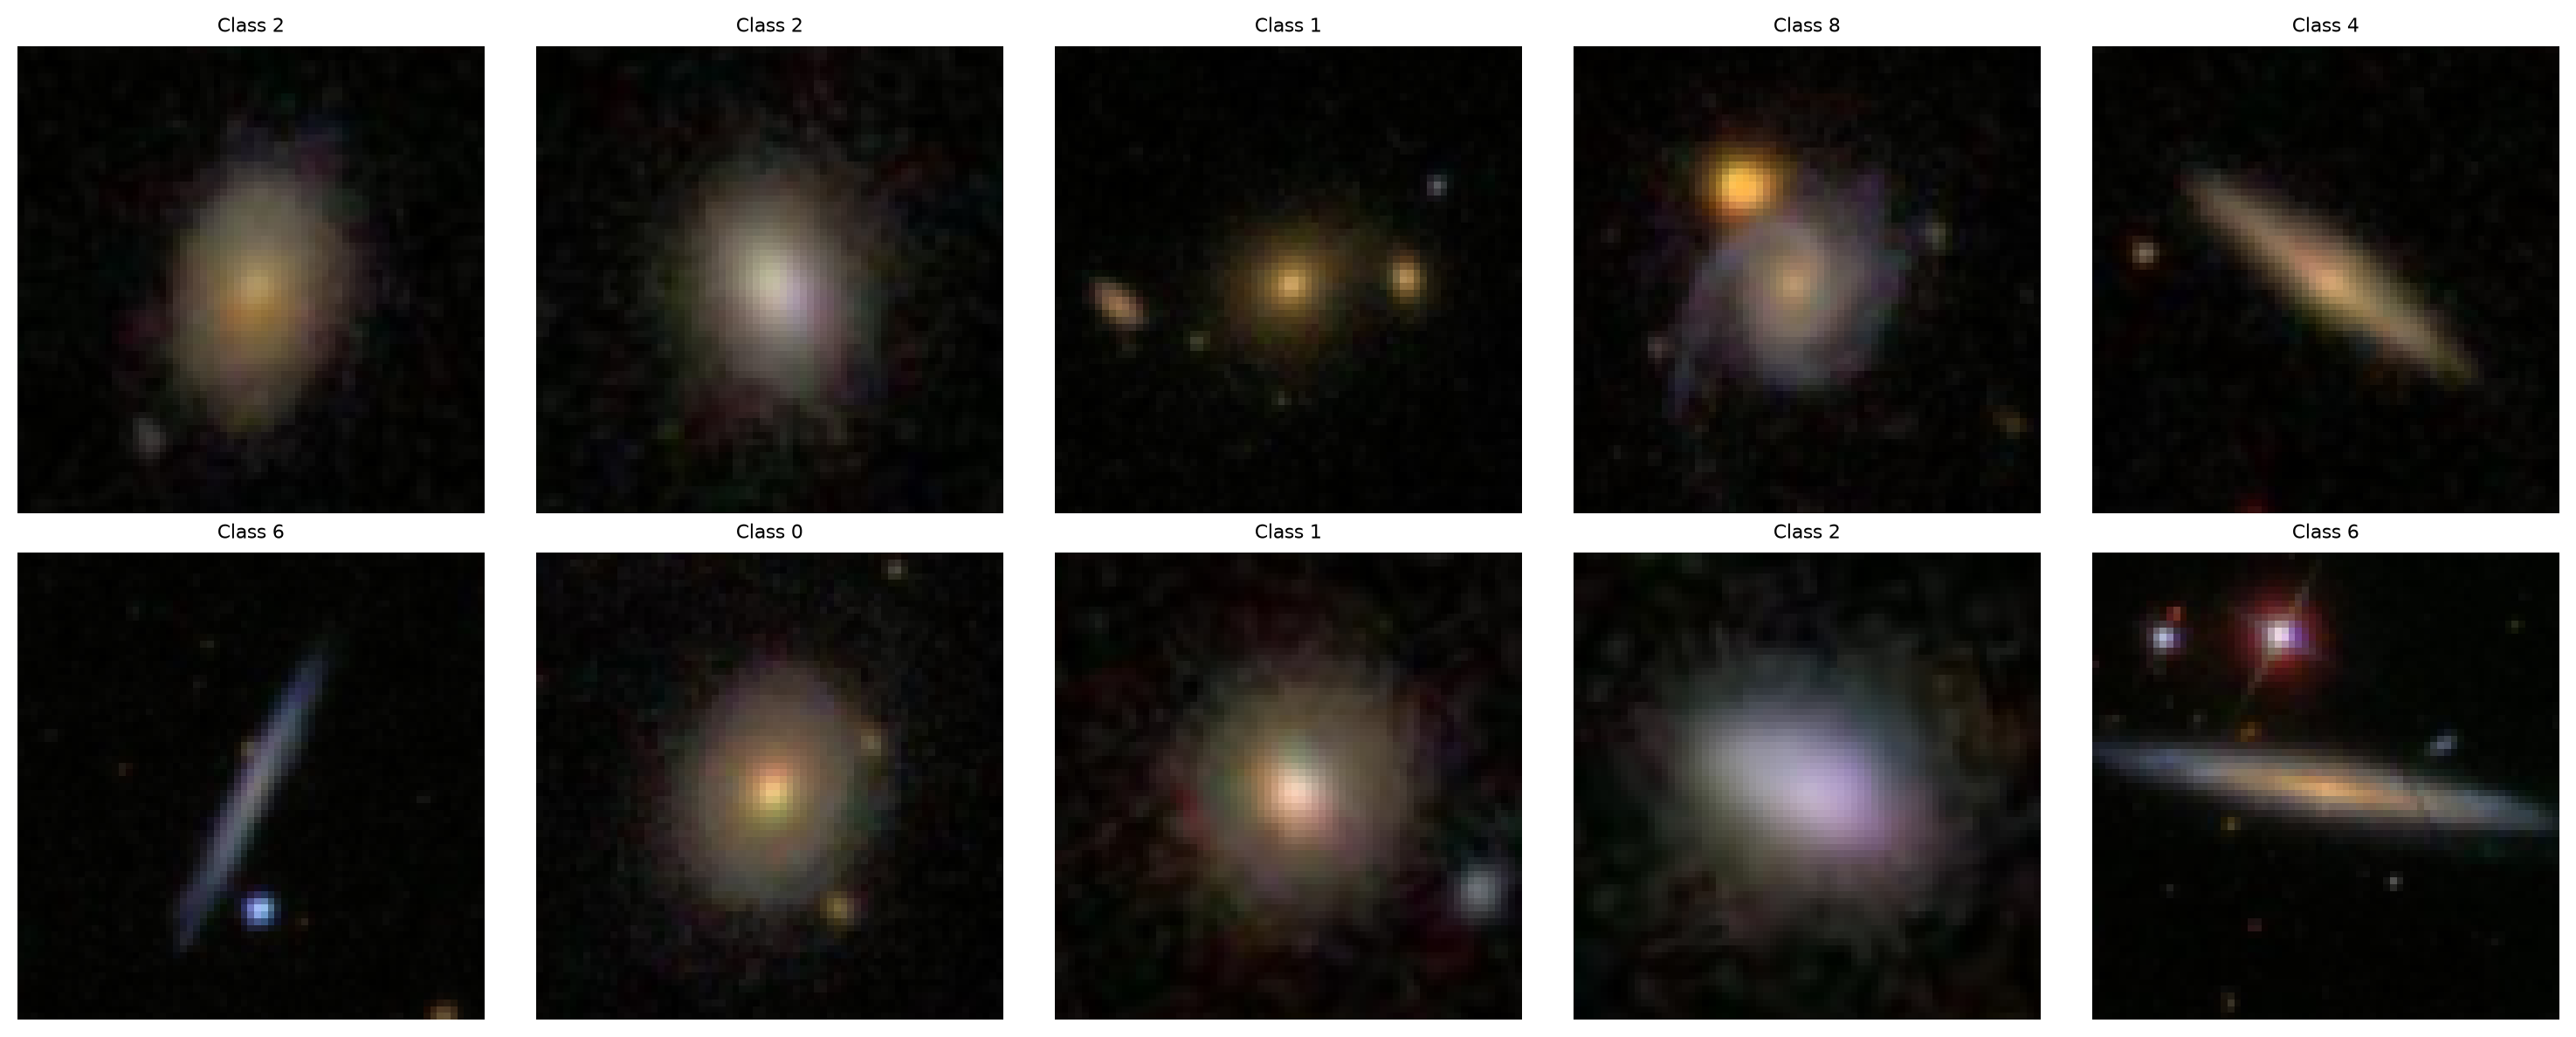

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, y_train.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i].astype(np.uint8))
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("original.pdf")
plt.show()

In [7]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 128
# X_train_cropped = np.array([center_crop(img, crop_size) for img in X_train])
# X_test_cropped = np.array([center_crop(img, crop_size) for img in X_test])

# print(X_train_cropped.shape)

In [71]:
from PIL import Image
import numpy as np

X_train_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_train
])

X_test_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_test
])

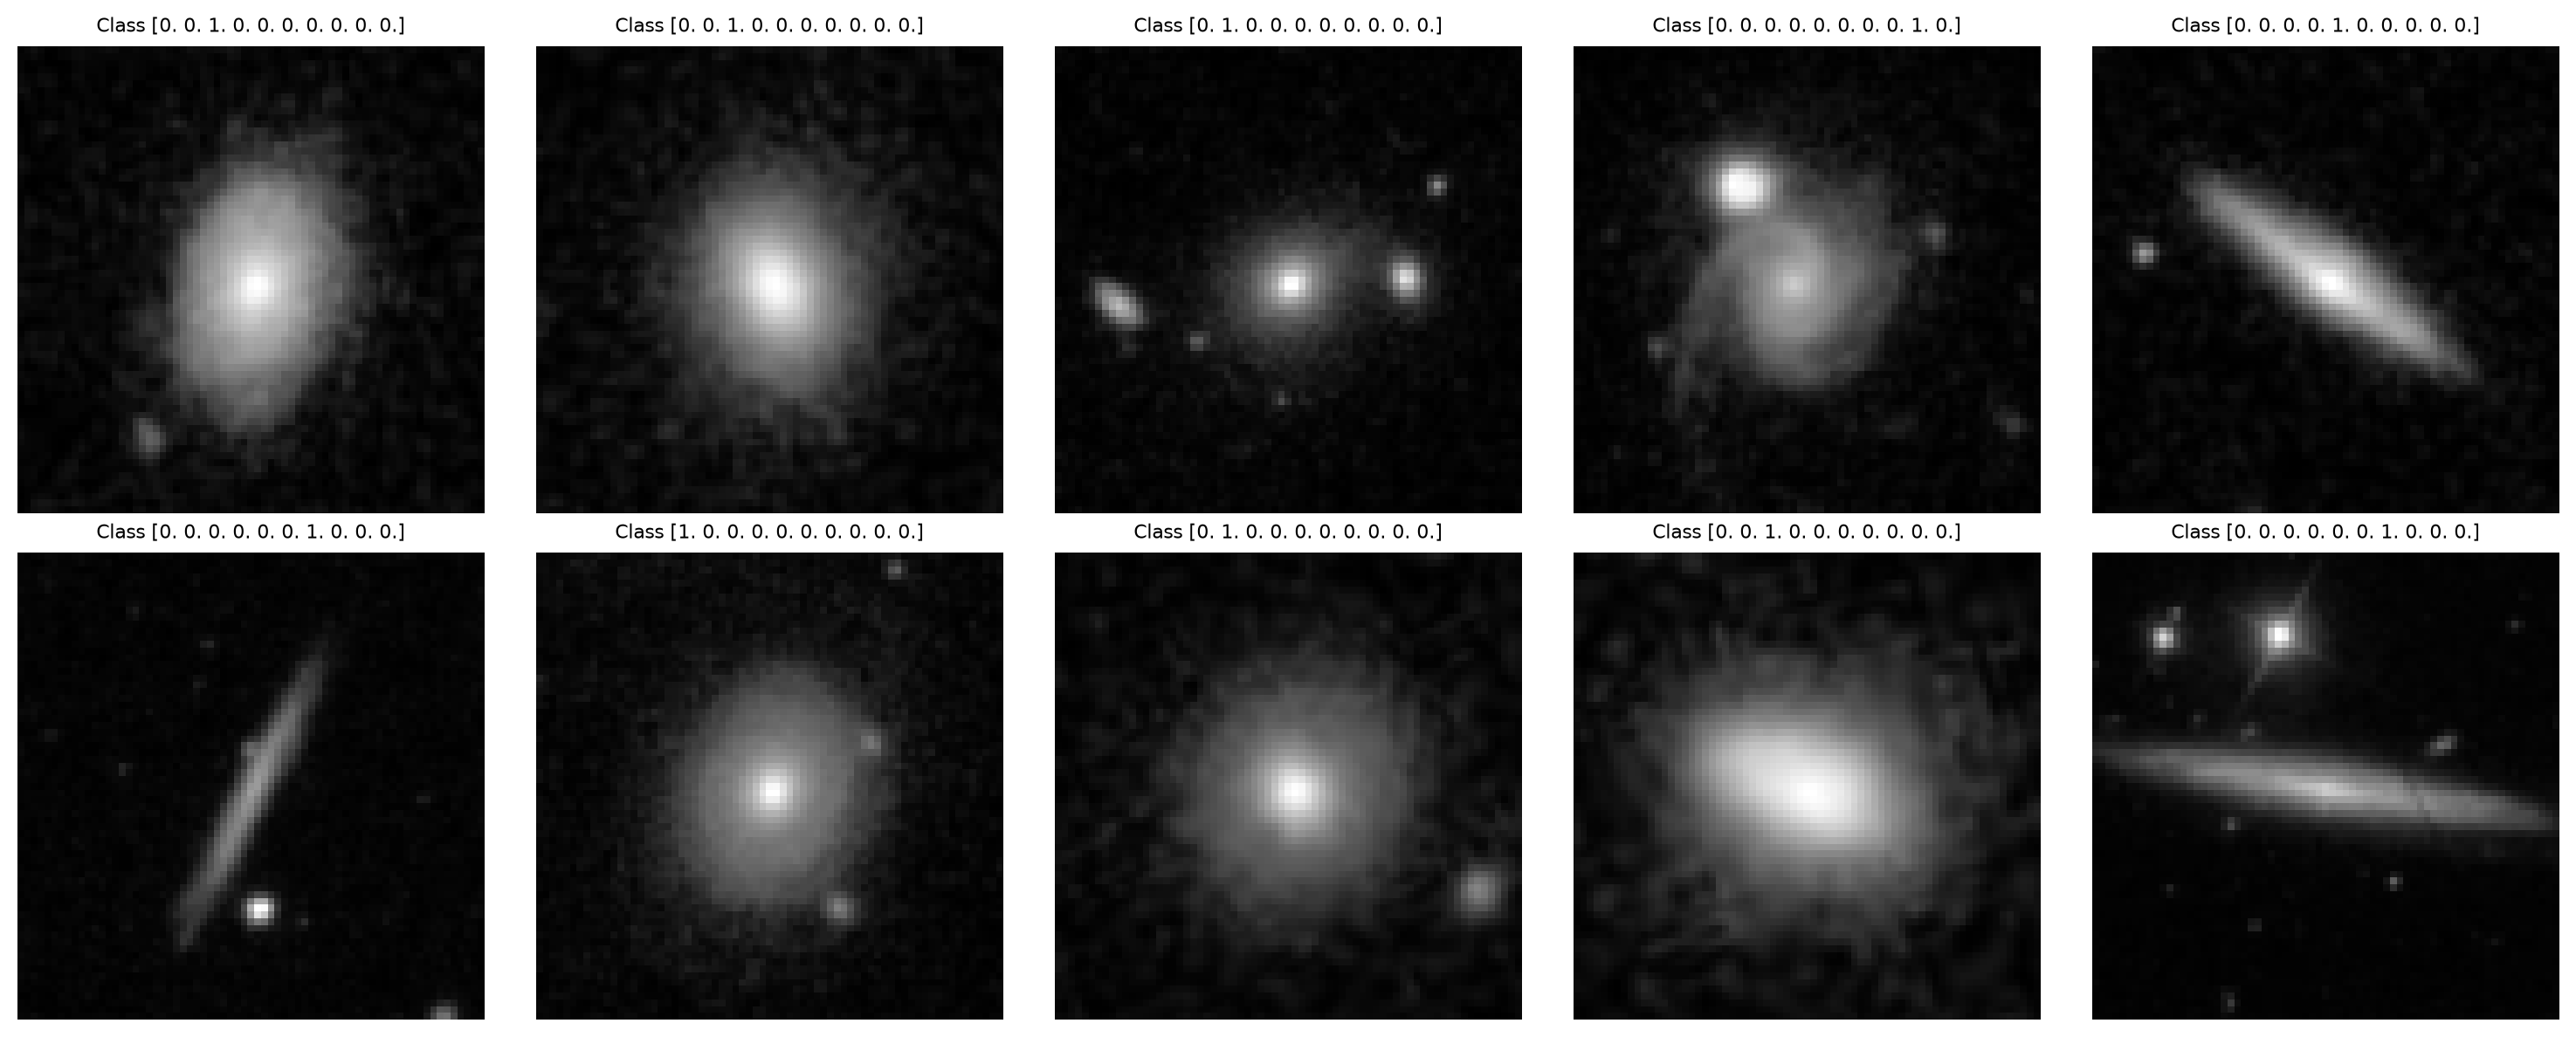

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_gray[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Cleaning

1. normalization (min-max)
2. normalization using percentiles
3. gaussian / bilateral filter
4. histogram equalization

In [10]:
# Min-max normalization (per-image)

X_min = X_train_gray.min(axis=(1,2), keepdims=True)  
X_max = X_train_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_train_gray - X_min) / (X_max - X_min + 1e-8)  

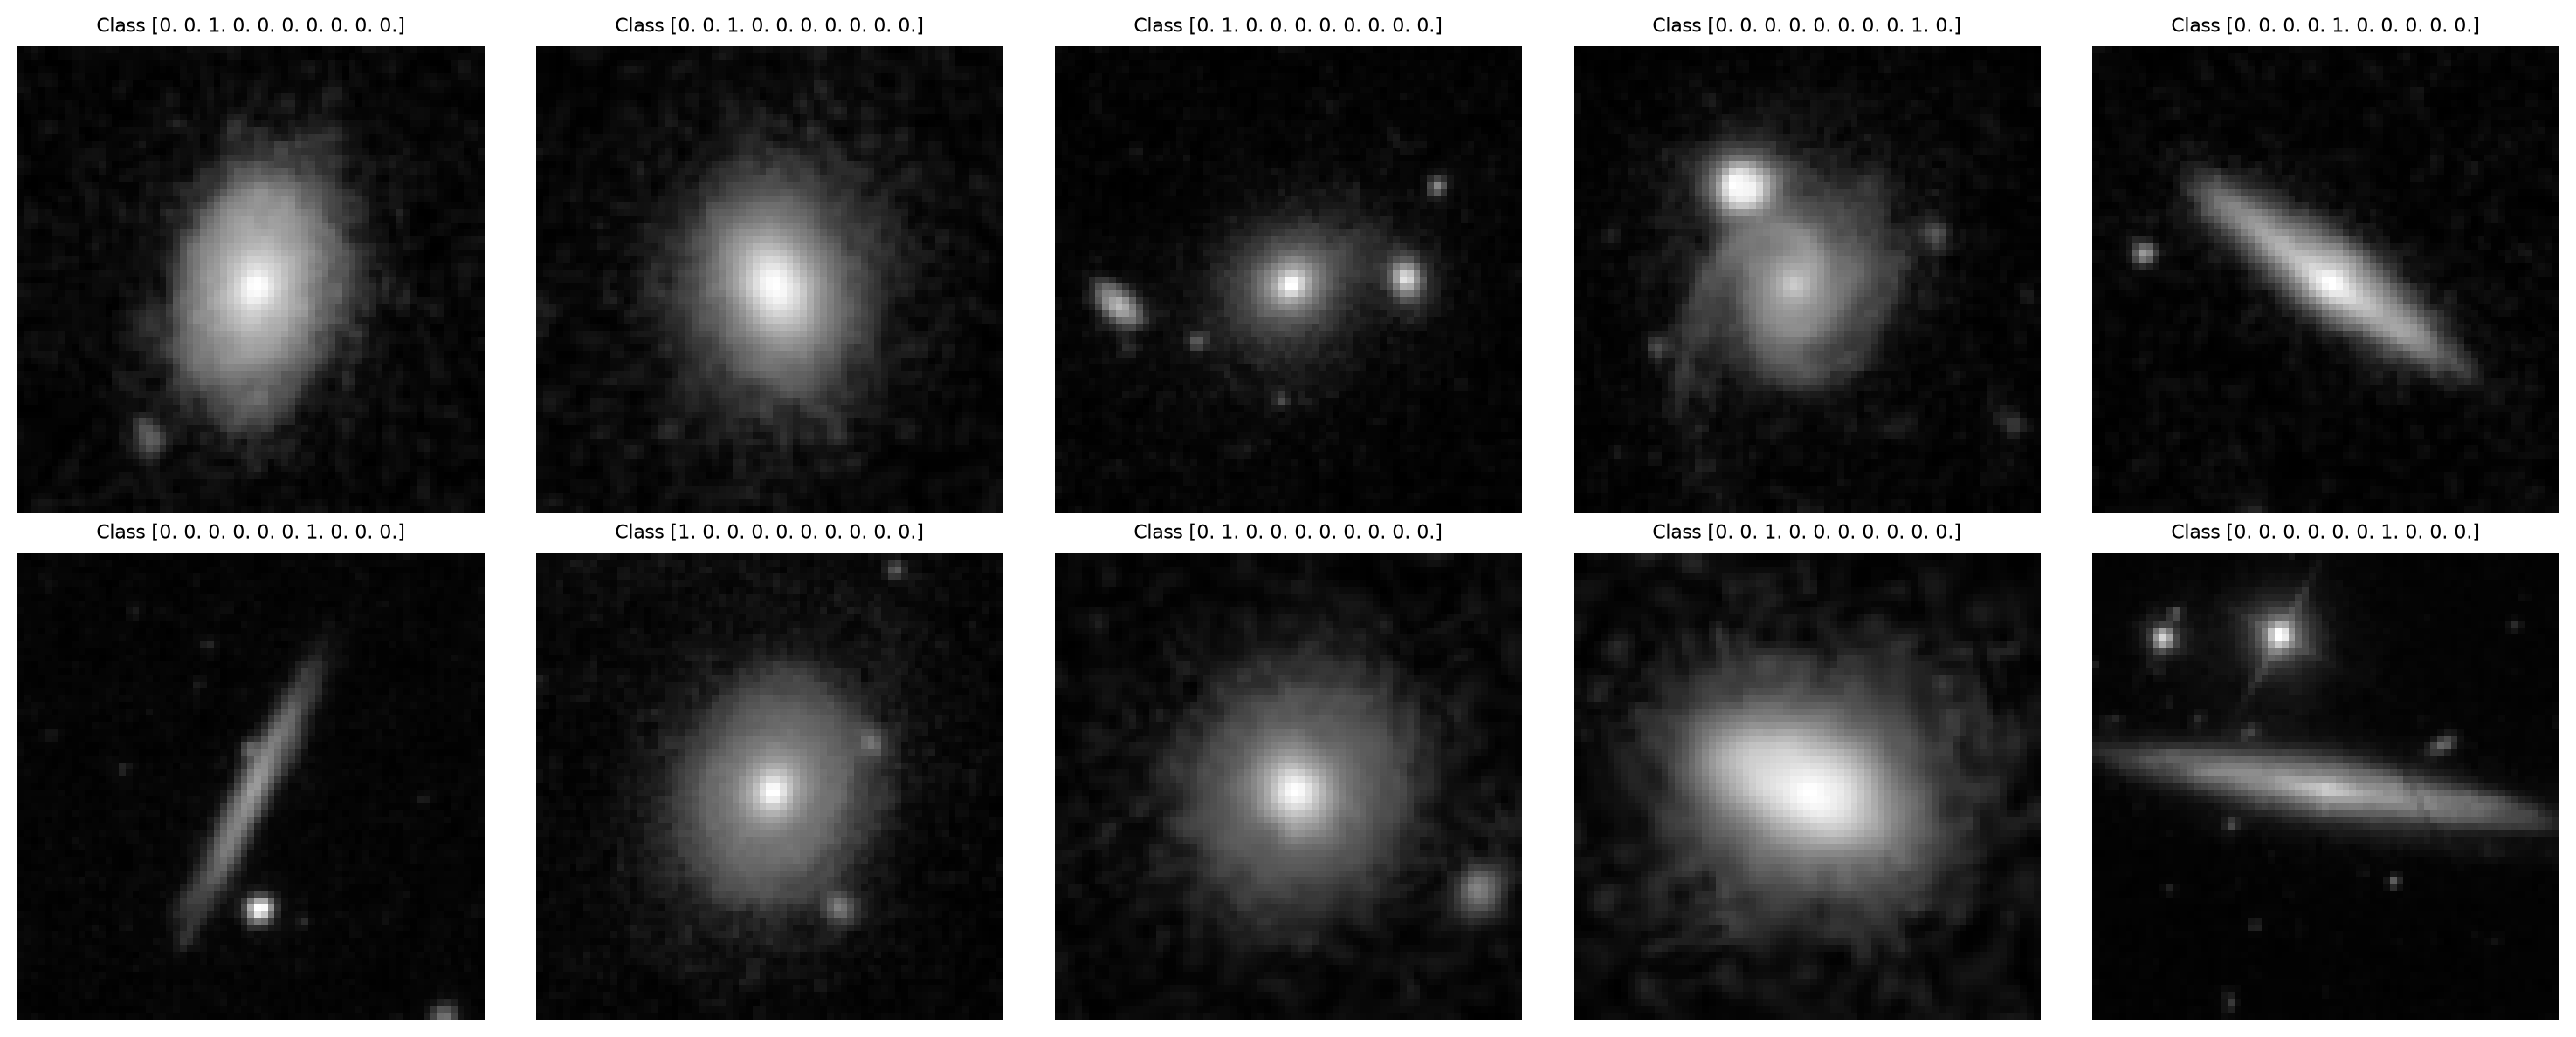

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_norm[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("gray_cropped.pdf")
plt.show()

In [12]:
X_norm.shape

(13071, 69, 69)

In [13]:
# gaussian filter on images

from scipy.ndimage import gaussian_filter

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])

In [14]:
X_gauss.min(), X_gauss.max()

(0.0, 0.9974658839905133)

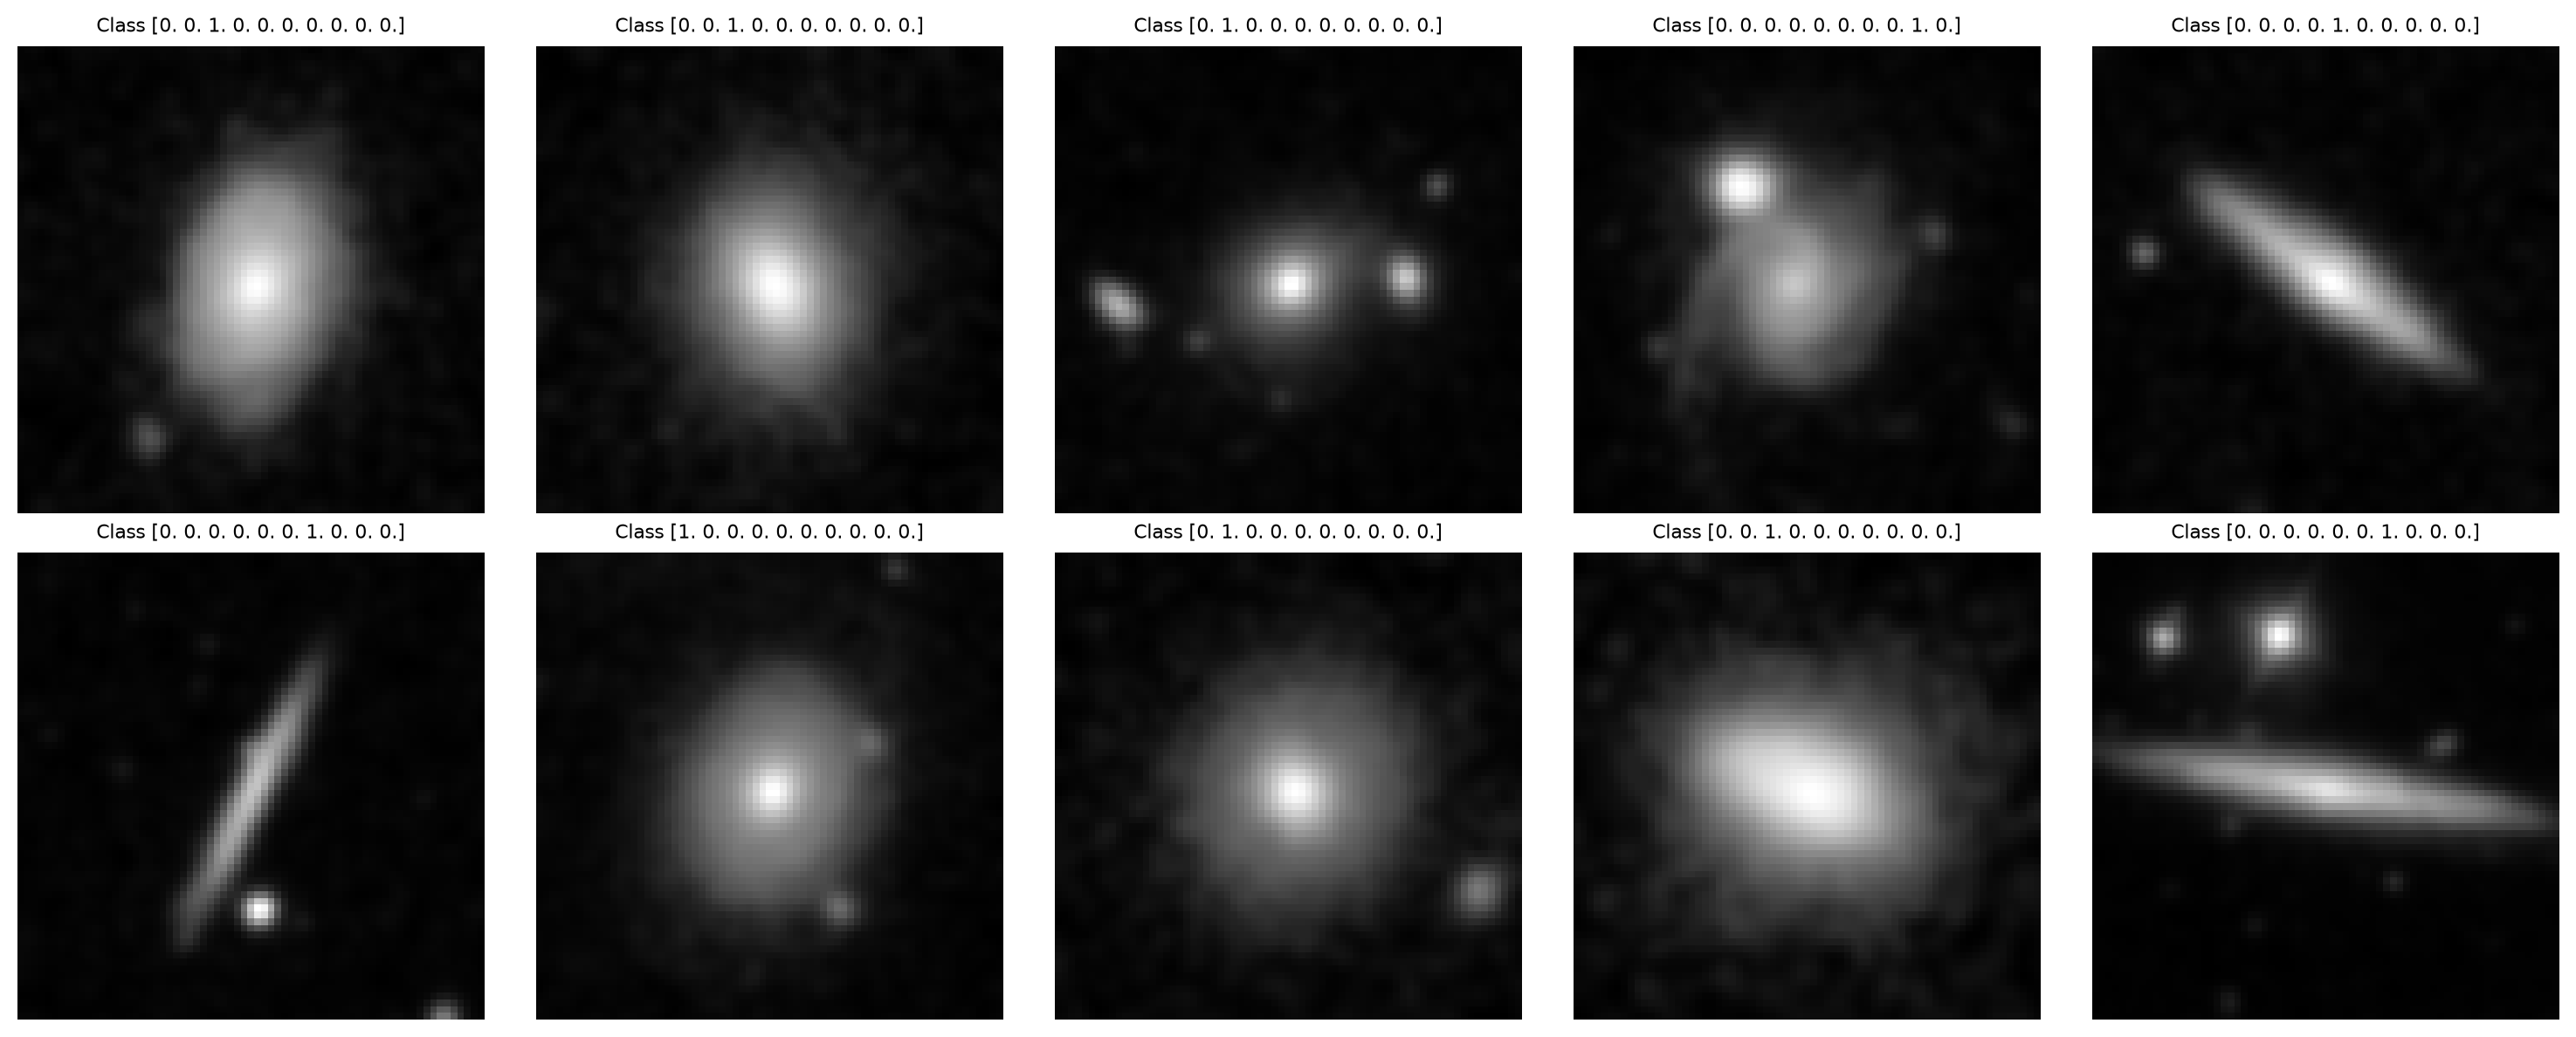

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_gauss[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("gaussian_smooth.pdf")
plt.show()

In [16]:
# train a model on X_norm (without filters) and X_gauss

X_norm.shape, y_train.shape

((13071, 69, 69), (13071, 10))

### Training

#### without filter

In [17]:
# train a CNN model

import tensorflow as tf
from keras import layers, models

In [18]:

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model = models.Sequential()

model.add(layers.Input(shape=(69, 69, 1)))

# block 1
model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# block 2
model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# block 3
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model.add(layers.Dense(10, activation='softmax'))

2026-07-08 12:36:21.228486: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-08 12:36:21.346475: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-08 12:36:21.346882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
X_norm.shape

(13071, 69, 69)

In [21]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_train, axis=1)


In [22]:
X_flat.shape

(13071, 69, 69, 1)

In [23]:
y_train.shape

(13071, 10)

In [24]:
history = model.fit(
    X_flat, y_train,
    epochs=20,
    batch_size=4,
    shuffle=True
)

2026-07-08 12:36:22.478385: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.
2026-07-08 12:36:22.739820: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.


Epoch 1/20


2026-07-08 12:36:24.534396: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-07-08 12:36:24.614462: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-08 12:36:25.007585: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-07-08 12:36:25.441167: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f1020619620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-08 12:36:25.441211: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-07-08 12:36:25.447179: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783506985.537857   20074 device_compiler.

3268/3268 [==============================] - 22s 6ms/step - loss: 0.2096 - accuracy: 0.4889
Epoch 2/20
3268/3268 [==============================] - 16s 5ms/step - loss: 0.1581 - accuracy: 0.6489
Epoch 3/20
3268/3268 [==============================] - 16s 5ms/step - loss: 0.1415 - accuracy: 0.6857
Epoch 4/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1320 - accuracy: 0.7161
Epoch 5/20
3268/3268 [==============================] - 16s 5ms/step - loss: 0.1252 - accuracy: 0.7299
Epoch 6/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1194 - accuracy: 0.7498
Epoch 7/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1149 - accuracy: 0.7587
Epoch 8/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1119 - accuracy: 0.7686
Epoch 9/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1092 - accuracy: 0.7781
Epoch 10/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.1067

In [25]:
y = model.predict(X_flat)

2026-07-08 12:41:36.368609: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.
2026-07-08 12:41:36.667372: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 248924124 exceeds 10% of free system memory.


409/409 [==============================] - 2s 3ms/step


In [36]:
y_pred = (y > 0.5).astype(int)
y_pred = np.argmax(y_class, axis=1)

In [37]:
y_true = np.argmax(y_train, axis=1)

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, y_true)

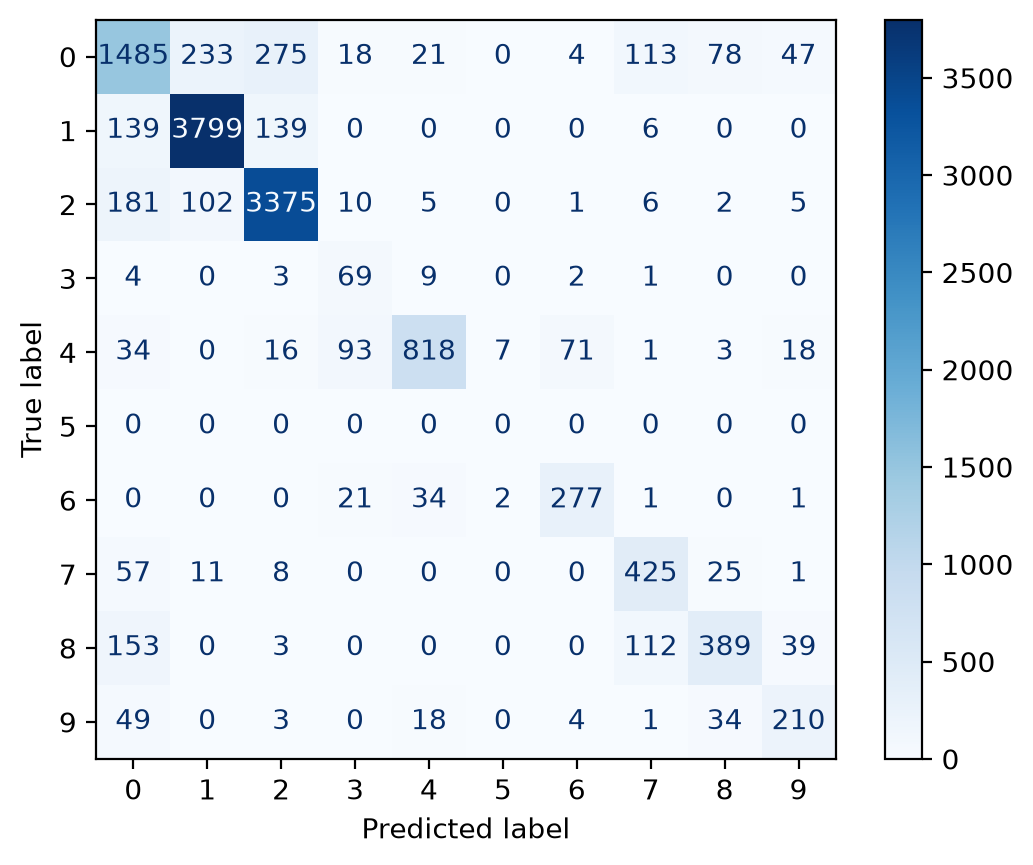

In [40]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()

#### with filter

In [49]:
X_flat_gauss = X_gauss[..., np.newaxis]

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model2 = models.Sequential()
model2.add(layers.Input(shape=(69, 69, 1)))

# block 1
model2.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2, 2)))

# block 2
model2.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model2.add(layers.MaxPooling2D((2, 2)))

# block 3
model2.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model2.add(layers.GlobalAveragePooling2D())

model2.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model2.add(layers.Dense(10, activation='softmax'))

In [50]:
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [106]:
history = model2.fit(
    X_flat_gauss, y_train,
    epochs=20,
    batch_size=4,
    shuffle=True
)

Epoch 1/20
3268/3268 [==============================] - 18s 5ms/step - loss: 0.0901 - accuracy: 0.8129
Epoch 2/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.0880 - accuracy: 0.8253
Epoch 3/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.0881 - accuracy: 0.8195
Epoch 4/20
3268/3268 [==============================] - 17s 5ms/step - loss: 0.0866 - accuracy: 0.8271
Epoch 5/20
3268/3268 [==============================] - 16s 5ms/step - loss: 0.0846 - accuracy: 0.8295
Epoch 6/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.0833 - accuracy: 0.8330
Epoch 7/20
3268/3268 [==============================] - 16s 5ms/step - loss: 0.0822 - accuracy: 0.8328
Epoch 8/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.0813 - accuracy: 0.8344
Epoch 9/20
3268/3268 [==============================] - 15s 5ms/step - loss: 0.0800 - accuracy: 0.8378
Epoch 10/20
3268/3268 [==============================] - 15s 5ms/step - l

In [52]:
y_gauss = model2.predict(X_flat_gauss)
y_pred = (y_gauss > 0.5).astype(int)
y_pred = np.argmax(y_gauss, axis=1)

409/409 [==============================] - 1s 3ms/step


In [53]:
y_true = np.argmax(y_train, axis=1)

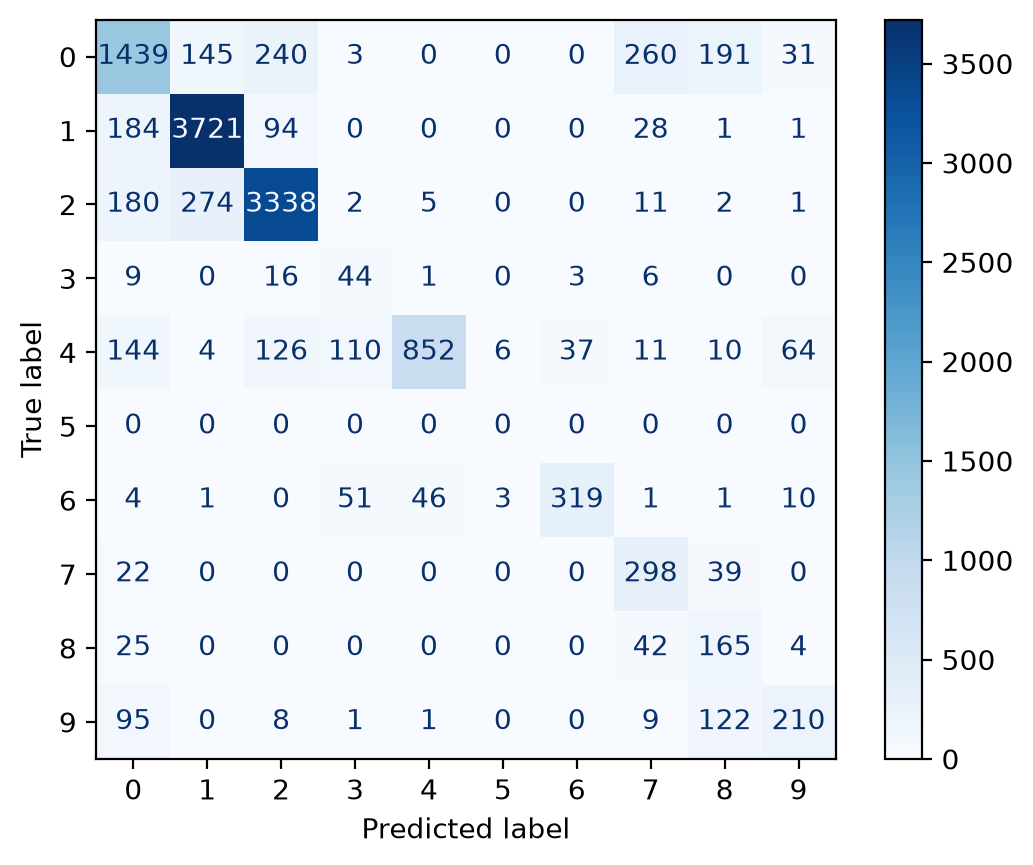

In [54]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()

### Testing

#### without filter

In [72]:
X_test_gray.shape

(8714, 69, 69)

In [92]:
# Min-max normalization (per-image)

X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

In [93]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_test, axis=1)

In [96]:
y_pred = model.predict(X_flat)
y_pred = (y_pred > 0.5).astype(int)
y_pred = np.argmax(y_pred, axis=1)

273/273 [==============================] - 1s 3ms/step


In [97]:
y_true = np.argmax(y_test, axis=1)

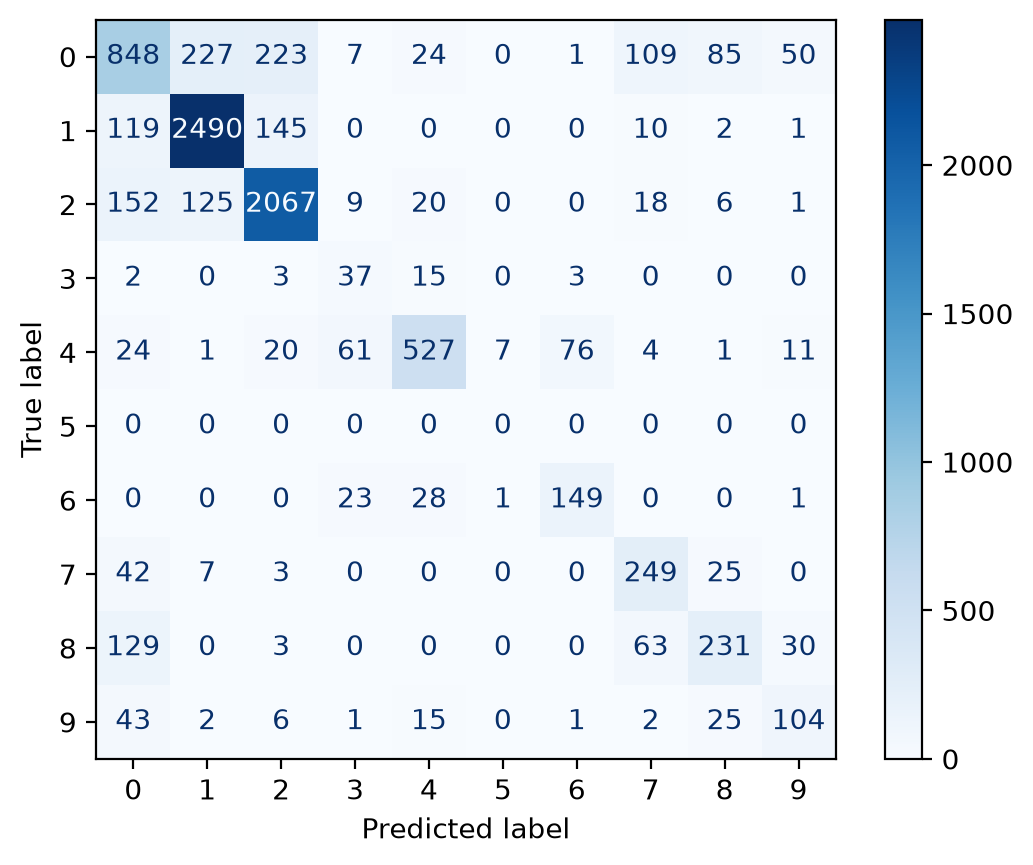

In [98]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()

In [103]:
X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])
X_flat = X_gauss[..., np.newaxis]

In [104]:
y_pred = model2.predict(X_flat)
y_pred = (y_pred > 0.5).astype(int)
y_pred = np.argmax(y_pred, axis=1)

273/273 [==============================] - 1s 3ms/step


with filter

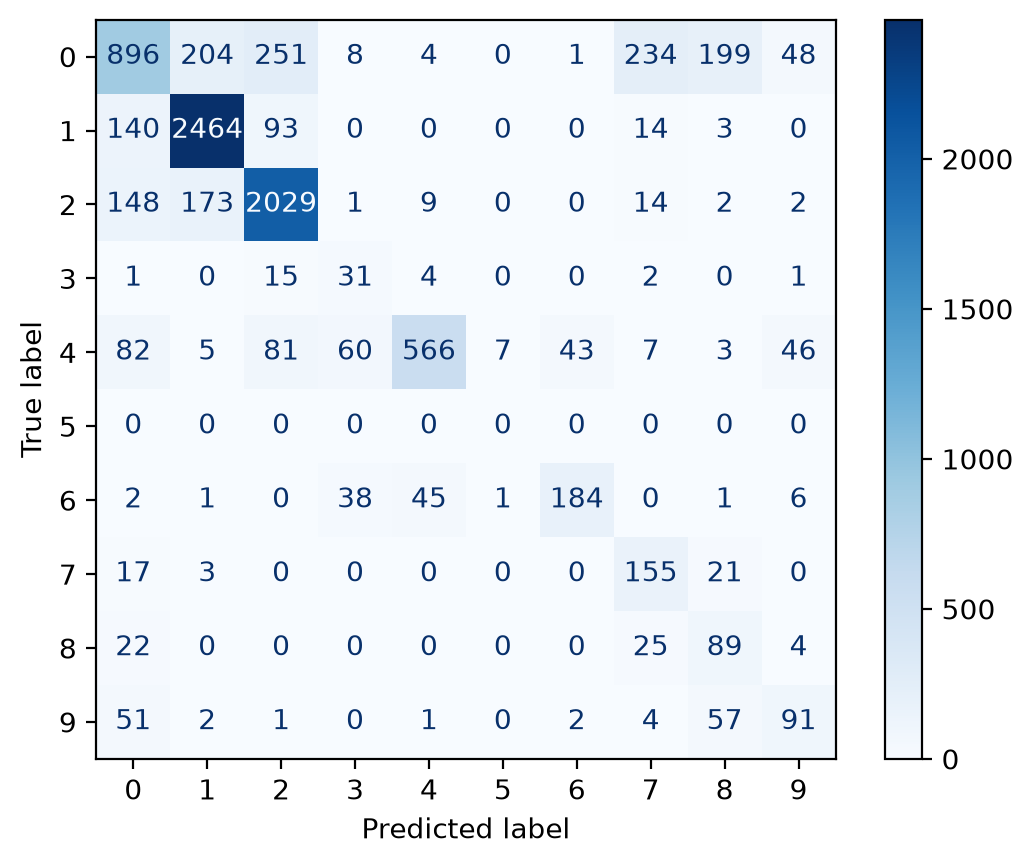

In [105]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()